# Análise de indicadores de saúde mental na Paraíba (2015-2025)

> Relatório final desenvolvido em Jupyter Notebook.

Este relatório investiga internações hospitalares associadas a indicadores de saúde mental na Paraíba entre 2015 e 2025. O foco está na evolução temporal das internações, nos grupos diagnósticos, no perfil demográfico, no tempo de permanência, na mortalidade e nos gastos hospitalares.

**Observação:** adicione os nomes dos integrantes antes da entrega.


## 1. Introdução

A saúde mental representa uma dimensão importante da saúde pública. Dados hospitalares permitem observar mudanças na demanda por internações, no perfil dos pacientes e nos recursos utilizados no atendimento.

### Objetivo geral

Analisar indicadores relacionados às internações por episódios depressivos, transtorno depressivo recorrente e transtornos ansiosos na Paraíba entre 2015 e 2025.

### Perguntas da análise

1. Como evoluiu o número anual de internações?
2. Qual é a participação de cada grupo diagnóstico?
3. Como as internações se distribuem por sexo?
4. O perfil etário dos pacientes mudou ao longo do período?
5. Como evoluiu o tempo de permanência hospitalar?
6. Qual foi o comportamento da mortalidade hospitalar?
7. Como evoluíram os gastos hospitalares?
8. Existe uma tendência linear na idade mediana das internações por episódio depressivo?


## 2. Bibliotecas e configurações

Execute a célula abaixo antes das demais. Caso alguma biblioteca não esteja instalada, use:

```bash
pip install pandas pyarrow matplotlib seaborn scikit-learn
```


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

CAMINHO_SIH = Path(
    "data/processed/sih/sih_pb_2015_2025_saude_mental.parquet"
)

PASTA_SAIDA = Path("graficos")
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

print("Configuração concluída.")

Configuração concluída.


## 3. Dados utilizados

A principal fonte desta etapa é o Sistema de Informações Hospitalares do SUS (SIH/SUS). Cada registro representa uma internação hospitalar incluída no recorte da pesquisa.

Principais variáveis:

- `ANO_CMPT`: ano da competência;
- `MES_CMPT`: mês da competência;
- `DIAG_PRINC`: diagnóstico principal;
- `IDADE`: idade do paciente;
- `SEXO`: código do sexo;
- `DIAS_PERM`: quantidade de dias de permanência;
- `MORTE`: indicador de óbito;
- `VAL_TOT`: valor total da internação.


In [3]:
if not CAMINHO_SIH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {CAMINHO_SIH}\n"
        "Confirme se o notebook está sendo executado na raiz do projeto."
    )

df_original = pd.read_parquet(CAMINHO_SIH)

print(f"Dimensões do dataset: {df_original.shape}")
display(df_original.head())

Dimensões do dataset: (874, 11)


,UF_ZI,ANO_CMPT,MES_CMPT,MUNIC_RES,MUNIC_MOV,DIAG_PRINC,IDADE,SEXO,DIAS_PERM,MORTE,VAL_TOT
0,250400,2015,01,250600,250400,F333,22,3,31,0,1540.74
1,250400,2015,01,250830,250400,F323,52,3,35,0,1739.54
2,250750,2015,01,250140,250750,F323,44,3,27,0,1292.23
3,250750,2015,01,250180,250750,F323,39,1,4,0,248.50
4,250750,2015,01,250180,250750,F323,39,1,12,0,546.71


In [4]:
print("Tipos das colunas:")
display(df_original.dtypes.to_frame("tipo"))

print("\nQuantidade de valores ausentes:")
display(
    df_original.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("ausentes")
)

Tipos das colunas:


,tipo
UF_ZI,object
ANO_CMPT,object
MES_CMPT,object
MUNIC_RES,object
MUNIC_MOV,object
DIAG_PRINC,object
IDADE,object
SEXO,object
DIAS_PERM,object
MORTE,object



Quantidade de valores ausentes:


,ausentes
UF_ZI,0
ANO_CMPT,0
MES_CMPT,0
MUNIC_RES,0
MUNIC_MOV,0
DIAG_PRINC,0
IDADE,0
SEXO,0
DIAS_PERM,0
MORTE,0


## 4. Pré-processamento

As decisões adotadas foram:

- conversão das colunas numéricas;
- padronização do diagnóstico principal;
- criação de grupos diagnósticos a partir do CID;
- tradução dos códigos de sexo;
- remoção de idades fora do intervalo de 0 a 120 anos;
- preservação dos registros originais em `df_original`;
- criação de uma nova base tratada chamada `df`.

Os grupos analisados são:

- F32: episódio depressivo;
- F33: transtorno depressivo recorrente;
- F41: transtornos ansiosos.


In [5]:
df = df_original.copy()

colunas_numericas = [
    "ANO_CMPT",
    "MES_CMPT",
    "IDADE",
    "SEXO",
    "DIAS_PERM",
    "MORTE",
    "VAL_TOT"
]

for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

df["DIAG_PRINC"] = (
    df["DIAG_PRINC"]
    .fillna("")
    .astype(str)
    .str.upper()
    .str.strip()
)

condicoes = [
    df["DIAG_PRINC"].str.startswith("F32"),
    df["DIAG_PRINC"].str.startswith("F33"),
    df["DIAG_PRINC"].str.startswith("F41")
]

grupos = [
    "Episódio depressivo",
    "Transtorno depressivo recorrente",
    "Transtornos ansiosos"
]

df["GRUPO_CID"] = np.select(
    condicoes,
    grupos,
    default="Outros"
)

df = df[df["GRUPO_CID"] != "Outros"].copy()

mapa_sexo = {
    1: "Masculino",
    3: "Feminino"
}

df["SEXO_DESCRICAO"] = (
    df["SEXO"]
    .map(mapa_sexo)
    .fillna("Não informado")
)

df["IDADE_VALIDA"] = df["IDADE"].where(
    df["IDADE"].between(0, 120)
)

df["MORTE"] = df["MORTE"].fillna(0)
df["MORTE"] = (df["MORTE"] > 0).astype(int)

df = df[df["ANO_CMPT"].between(2015, 2025)].copy()
df["ANO_CMPT"] = df["ANO_CMPT"].astype(int)

print(f"Registros após o pré-processamento: {len(df)}")
display(df.head())

Registros após o pré-processamento: 874


,UF_ZI,ANO_CMPT,MES_CMPT,MUNIC_RES,MUNIC_MOV,DIAG_PRINC,IDADE,SEXO,DIAS_PERM,MORTE,VAL_TOT,GRUPO_CID,SEXO_DESCRICAO,IDADE_VALIDA
0,250400,2015,1,250600,250400,F333,22,3,31,0,"1,540.74",Transtorno depressivo recorrente,Feminino,22
1,250400,2015,1,250830,250400,F323,52,3,35,0,"1,739.54",Episódio depressivo,Feminino,52
2,250750,2015,1,250140,250750,F323,44,3,27,0,"1,292.23",Episódio depressivo,Feminino,44
3,250750,2015,1,250180,250750,F323,39,1,4,0,248.50,Episódio depressivo,Masculino,39
4,250750,2015,1,250180,250750,F323,39,1,12,0,546.71,Episódio depressivo,Masculino,39


In [6]:
resumo_qualidade = pd.DataFrame({
    "indicador": [
        "Registros originais",
        "Registros após filtro de CID",
        "Idades válidas",
        "Dias de permanência válidos",
        "Valores hospitalares válidos"
    ],
    "quantidade": [
        len(df_original),
        len(df),
        df["IDADE_VALIDA"].notna().sum(),
        df["DIAS_PERM"].notna().sum(),
        df["VAL_TOT"].notna().sum()
    ]
})

display(resumo_qualidade)

,indicador,quantidade
0,Registros originais,874
1,Registros após filtro de CID,874
2,Idades válidas,874
3,Dias de permanência válidos,874
4,Valores hospitalares válidos,874


# 5. Perguntas e análises

## Pergunta 1 — Como evoluiu o número anual de internações?

O número de registros é agrupado por ano. Um gráfico de linhas é utilizado porque a ordem temporal é essencial para a interpretação.


,ANO_CMPT,internacoes
0,2015,77
1,2016,126
2,2017,21
3,2018,66
4,2019,40
5,2020,83
6,2021,21
7,2022,116
8,2023,65
9,2024,152


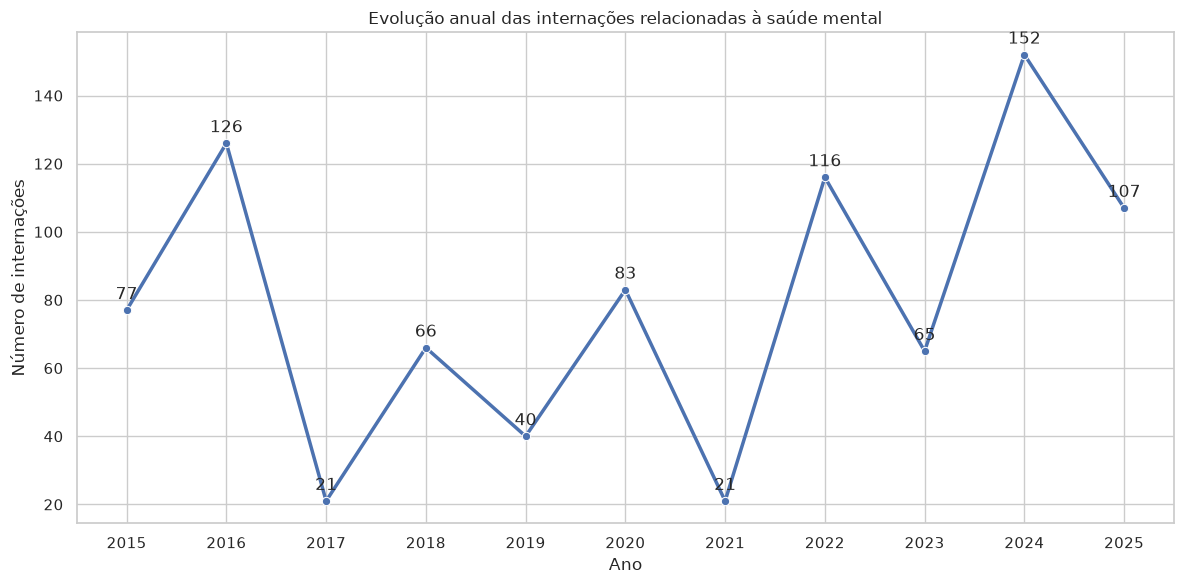

In [7]:
internacoes_anuais = (
    df.groupby("ANO_CMPT")
    .size()
    .reset_index(name="internacoes")
    .sort_values("ANO_CMPT")
)

display(internacoes_anuais)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=internacoes_anuais,
    x="ANO_CMPT",
    y="internacoes",
    marker="o",
    linewidth=2.5
)

for _, linha in internacoes_anuais.iterrows():
    plt.annotate(
        int(linha["internacoes"]),
        (linha["ANO_CMPT"], linha["internacoes"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.title("Evolução anual das internações relacionadas à saúde mental")
plt.xlabel("Ano")
plt.ylabel("Número de internações")
plt.xticks(internacoes_anuais["ANO_CMPT"])
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "01_internacoes_anuais.png", dpi=300)
plt.show()

In [8]:
ano_maior = internacoes_anuais.loc[
    internacoes_anuais["internacoes"].idxmax()
]

ano_menor = internacoes_anuais.loc[
    internacoes_anuais["internacoes"].idxmin()
]

print(
    f"O maior número de internações ocorreu em "
    f"{int(ano_maior['ANO_CMPT'])}, com "
    f"{int(ano_maior['internacoes'])} registros."
)

print(
    f"O menor número ocorreu em "
    f"{int(ano_menor['ANO_CMPT'])}, com "
    f"{int(ano_menor['internacoes'])} registros."
)

O maior número de internações ocorreu em 2024, com 152 registros.
O menor número ocorreu em 2017, com 21 registros.


## Pergunta 2 — Qual é a participação de cada grupo diagnóstico?

Um gráfico de barras permite comparar diretamente as quantidades e os percentuais dos grupos.


,grupo,internacoes,percentual
0,Episódio depressivo,629,71.97
1,Transtorno depressivo recorrente,206,23.57
2,Transtornos ansiosos,39,4.46


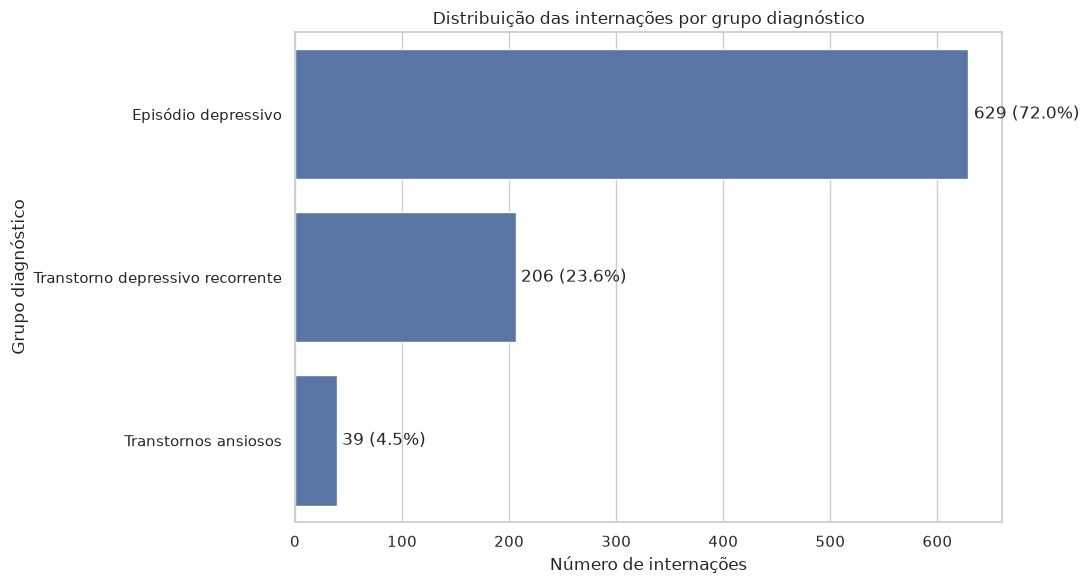

In [9]:
distribuicao_cid = (
    df["GRUPO_CID"]
    .value_counts()
    .rename_axis("grupo")
    .reset_index(name="internacoes")
)

distribuicao_cid["percentual"] = (
    distribuicao_cid["internacoes"]
    / distribuicao_cid["internacoes"].sum()
    * 100
)

display(distribuicao_cid)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=distribuicao_cid,
    x="internacoes",
    y="grupo"
)

for indice, linha in distribuicao_cid.iterrows():
    ax.text(
        linha["internacoes"] + 5,
        indice,
        f"{int(linha['internacoes'])} ({linha['percentual']:.1f}%)",
        va="center"
    )

plt.title("Distribuição das internações por grupo diagnóstico")
plt.xlabel("Número de internações")
plt.ylabel("Grupo diagnóstico")
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "02_distribuicao_diagnosticos.png", dpi=300)
plt.show()

## Pergunta 3 — Como as internações se distribuem por sexo?

A análise compara o número de internações por sexo dentro de cada grupo diagnóstico.


,GRUPO_CID,SEXO_DESCRICAO,internacoes
0,Episódio depressivo,Feminino,363
1,Episódio depressivo,Masculino,266
2,Transtorno depressivo recorrente,Feminino,145
3,Transtorno depressivo recorrente,Masculino,61
4,Transtornos ansiosos,Feminino,21
5,Transtornos ansiosos,Masculino,18


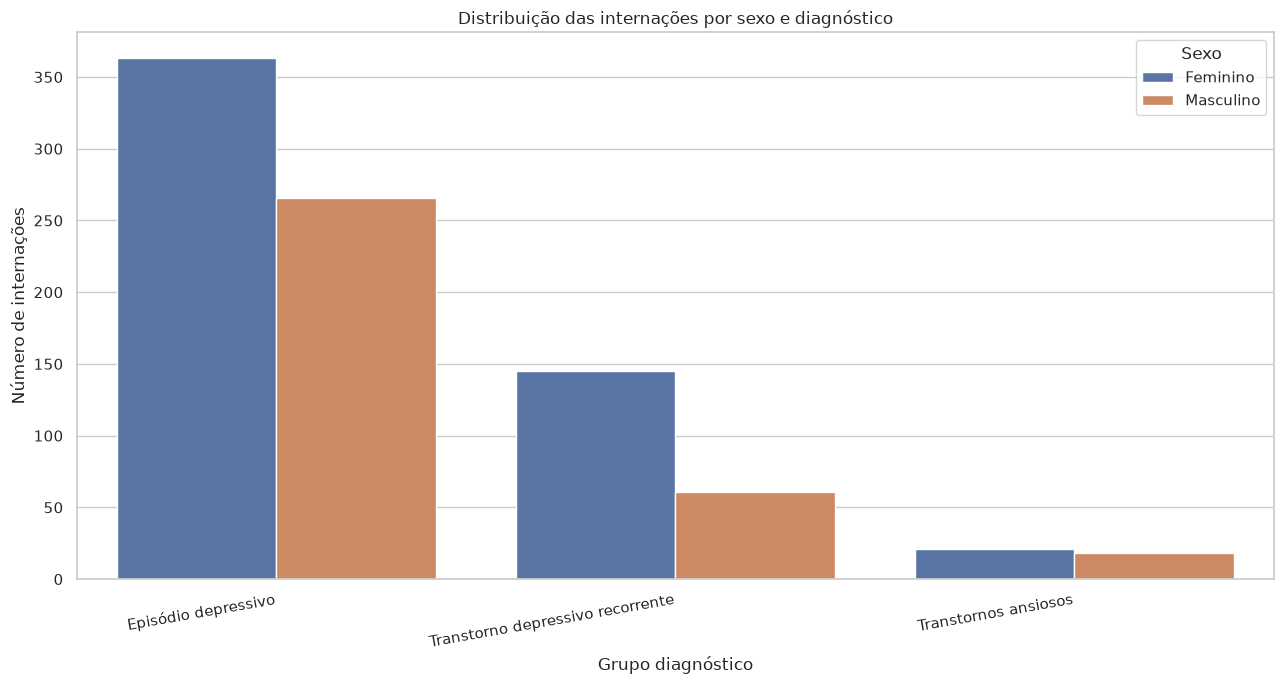

In [10]:
sexo_diagnostico = (
    df.groupby(["GRUPO_CID", "SEXO_DESCRICAO"])
    .size()
    .reset_index(name="internacoes")
)

display(sexo_diagnostico)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=sexo_diagnostico,
    x="GRUPO_CID",
    y="internacoes",
    hue="SEXO_DESCRICAO"
)

plt.title("Distribuição das internações por sexo e diagnóstico")
plt.xlabel("Grupo diagnóstico")
plt.ylabel("Número de internações")
plt.xticks(rotation=10, ha="right")
plt.legend(title="Sexo")
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "03_distribuicao_sexo.png", dpi=300)
plt.show()

In [11]:
sexo_total = (
    df["SEXO_DESCRICAO"]
    .value_counts()
    .rename_axis("sexo")
    .reset_index(name="internacoes")
)

sexo_total["percentual"] = (
    sexo_total["internacoes"]
    / sexo_total["internacoes"].sum()
    * 100
)

display(sexo_total)

,sexo,internacoes,percentual
0,Feminino,529,60.53
1,Masculino,345,39.47


## Pergunta 4 — O perfil etário dos pacientes mudou ao longo do período?

A mediana é utilizada como medida principal porque é menos sensível a idades extremas. Grupos com menos de 10 observações em determinado ano não são utilizados na linha de tendência descritiva.

Também é apresentado um boxplot, que permite observar mediana, quartis, dispersão e valores extremos.


,ANO_CMPT,GRUPO_CID,n,idade_mediana,idade_media,idade_minima,idade_maxima
0,2015,Episódio depressivo,50,39.00,41.28,18,73
1,2015,Transtorno depressivo recorrente,23,44.00,42.00,15,80
2,2015,Transtornos ansiosos,4,47.00,41.50,20,52
3,2016,Episódio depressivo,64,42.00,39.19,14,71
4,2016,Transtorno depressivo recorrente,39,47.00,42.90,24,60
5,2016,Transtornos ansiosos,23,41.00,38.61,8,65
6,2017,Episódio depressivo,10,33.50,37.70,19,64
7,2017,Transtorno depressivo recorrente,10,45.50,42.40,20,54
8,2017,Transtornos ansiosos,1,37.00,37.00,37,37
9,2018,Episódio depressivo,46,37.50,36.33,17,56


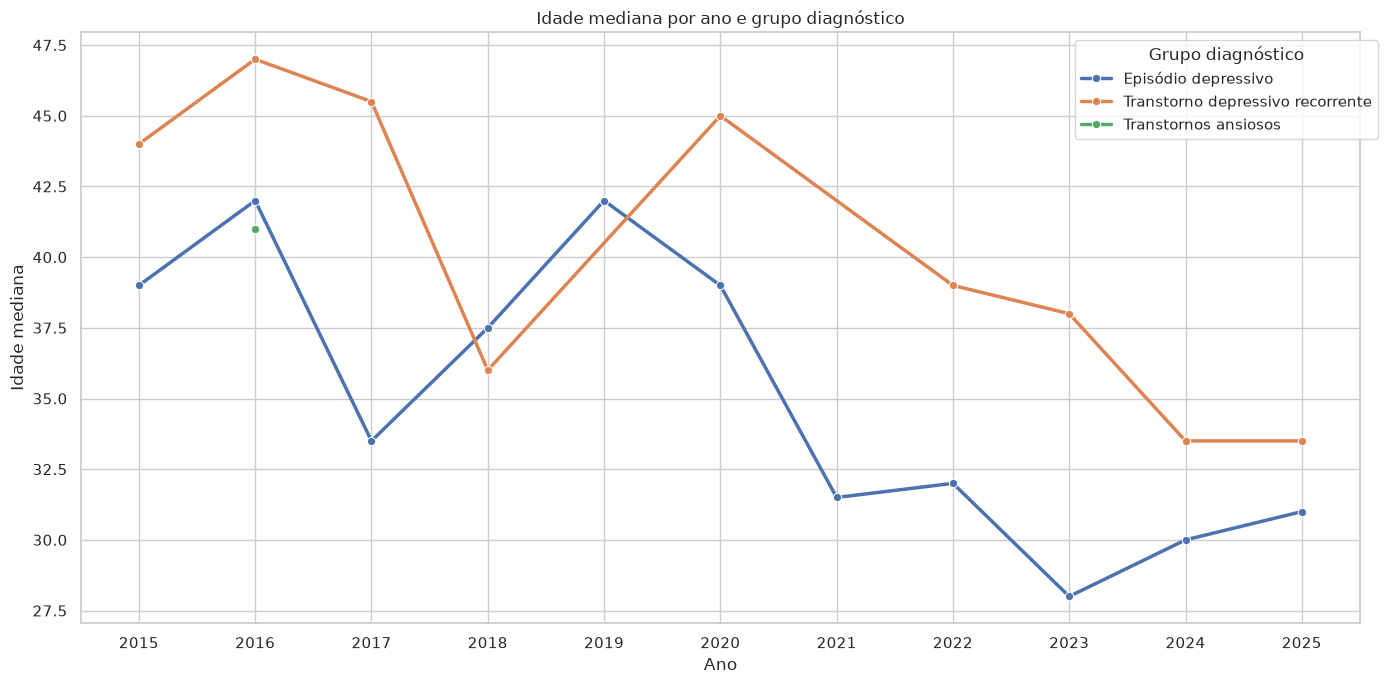

In [12]:
perfil_etario = (
    df.dropna(subset=["IDADE_VALIDA"])
    .groupby(["ANO_CMPT", "GRUPO_CID"])["IDADE_VALIDA"]
    .agg(
        n="count",
        idade_mediana="median",
        idade_media="mean",
        idade_minima="min",
        idade_maxima="max"
    )
    .reset_index()
)

perfil_etario_valido = perfil_etario[
    perfil_etario["n"] >= 10
].copy()

display(perfil_etario)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=perfil_etario_valido,
    x="ANO_CMPT",
    y="idade_mediana",
    hue="GRUPO_CID",
    marker="o",
    linewidth=2.5
)

plt.title("Idade mediana por ano e grupo diagnóstico")
plt.xlabel("Ano")
plt.ylabel("Idade mediana")
plt.xticks(sorted(df["ANO_CMPT"].unique()))
plt.legend(title="Grupo diagnóstico", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "04_idade_mediana.png", dpi=300)
plt.show()

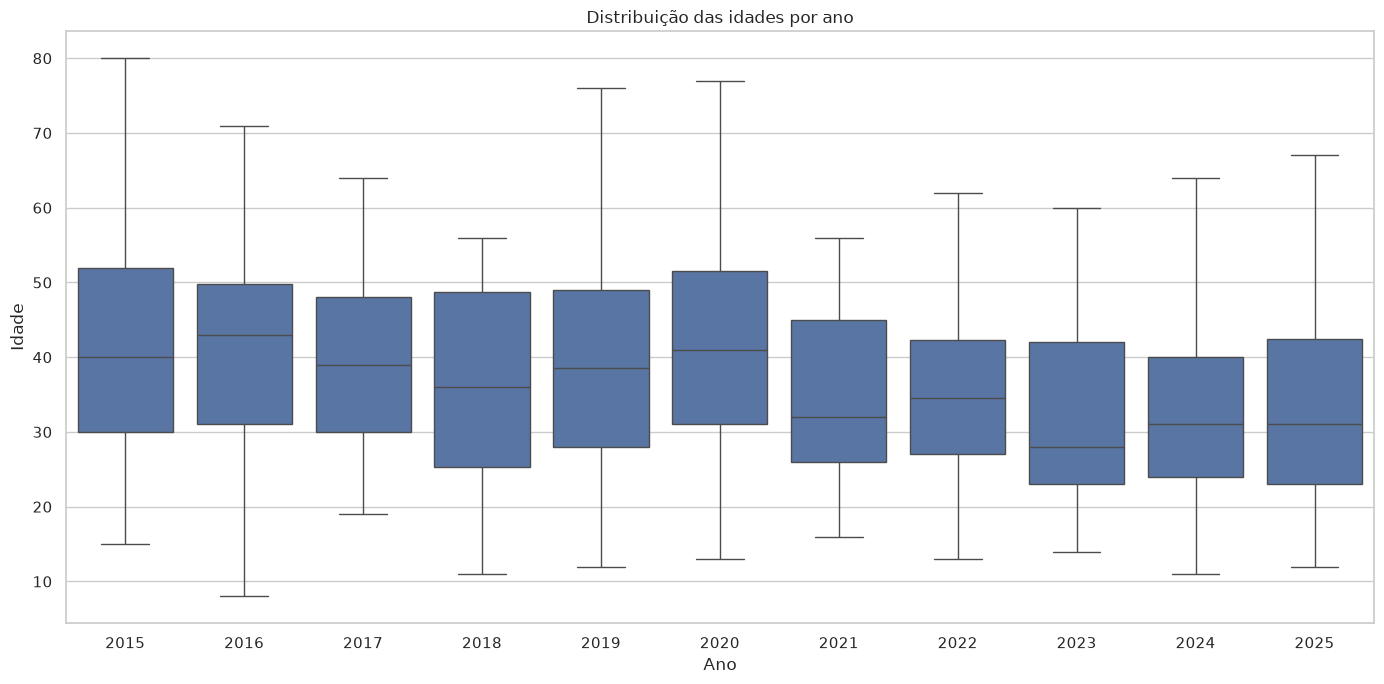

In [13]:
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df.dropna(subset=["IDADE_VALIDA"]),
    x="ANO_CMPT",
    y="IDADE_VALIDA",
    showfliers=False
)

plt.title("Distribuição das idades por ano")
plt.xlabel("Ano")
plt.ylabel("Idade")
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "05_boxplot_idade.png", dpi=300)
plt.show()

## Pergunta 5 — Como evoluiu o tempo de permanência hospitalar?

São comparadas a média e a mediana anual. A diferença entre elas ajuda a identificar a influência de internações muito longas.


,ANO_CMPT,internacoes,media_dias,mediana_dias,maximo_dias
0,2015,77,12.73,8.00,35
1,2016,126,11.56,8.00,44
2,2017,21,12.48,13.00,29
3,2018,66,10.68,5.50,31
4,2019,40,8.70,5.00,31
5,2020,83,9.61,3.00,31
6,2021,21,6.10,2.00,30
7,2022,116,7.05,3.00,31
8,2023,65,4.83,2.00,33
9,2024,152,4.16,3.00,30


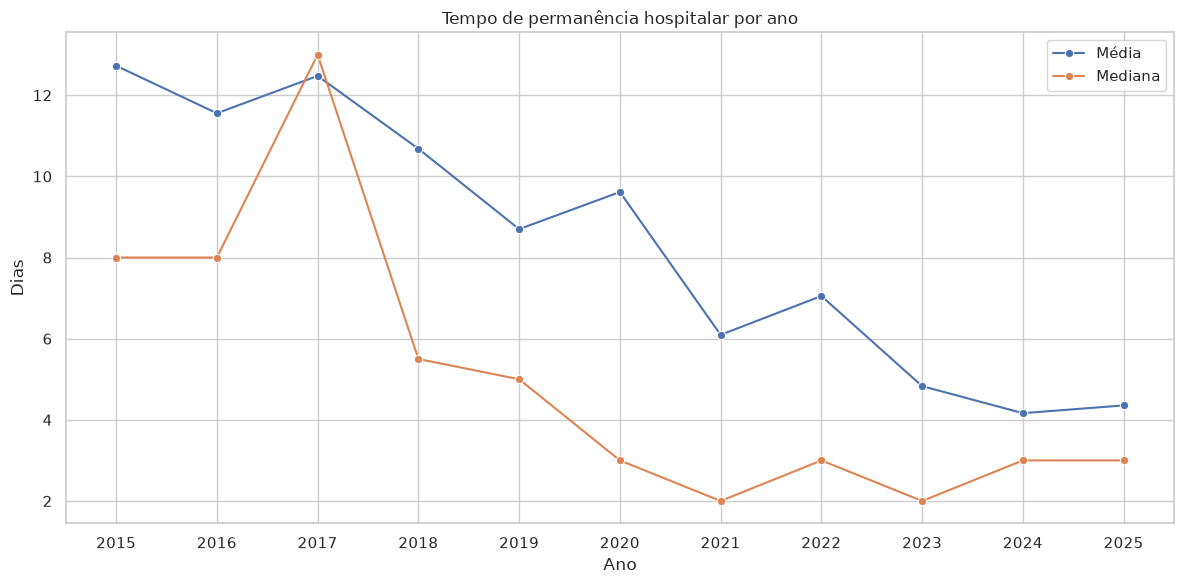

In [14]:
permanencia = df.dropna(subset=["DIAS_PERM"]).copy()
permanencia = permanencia[permanencia["DIAS_PERM"] >= 0]

permanencia_anual = (
    permanencia.groupby("ANO_CMPT")["DIAS_PERM"]
    .agg(
        internacoes="count",
        media_dias="mean",
        mediana_dias="median",
        maximo_dias="max"
    )
    .reset_index()
)

display(permanencia_anual)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=permanencia_anual,
    x="ANO_CMPT",
    y="media_dias",
    marker="o",
    label="Média"
)

sns.lineplot(
    data=permanencia_anual,
    x="ANO_CMPT",
    y="mediana_dias",
    marker="o",
    label="Mediana"
)

plt.title("Tempo de permanência hospitalar por ano")
plt.xlabel("Ano")
plt.ylabel("Dias")
plt.xticks(permanencia_anual["ANO_CMPT"])
plt.legend()
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "06_tempo_permanencia.png", dpi=300)
plt.show()

## Pergunta 6 — Qual foi o comportamento da mortalidade hospitalar?

A taxa é calculada como o número de óbitos dividido pelo número de internações, multiplicado por 100.


,ANO_CMPT,internacoes,obitos,taxa_mortalidade
0,2015,77,0,0.00
1,2016,126,0,0.00
2,2017,21,0,0.00
3,2018,66,0,0.00
4,2019,40,0,0.00
5,2020,83,0,0.00
6,2021,21,0,0.00
7,2022,116,0,0.00
8,2023,65,0,0.00
9,2024,152,0,0.00


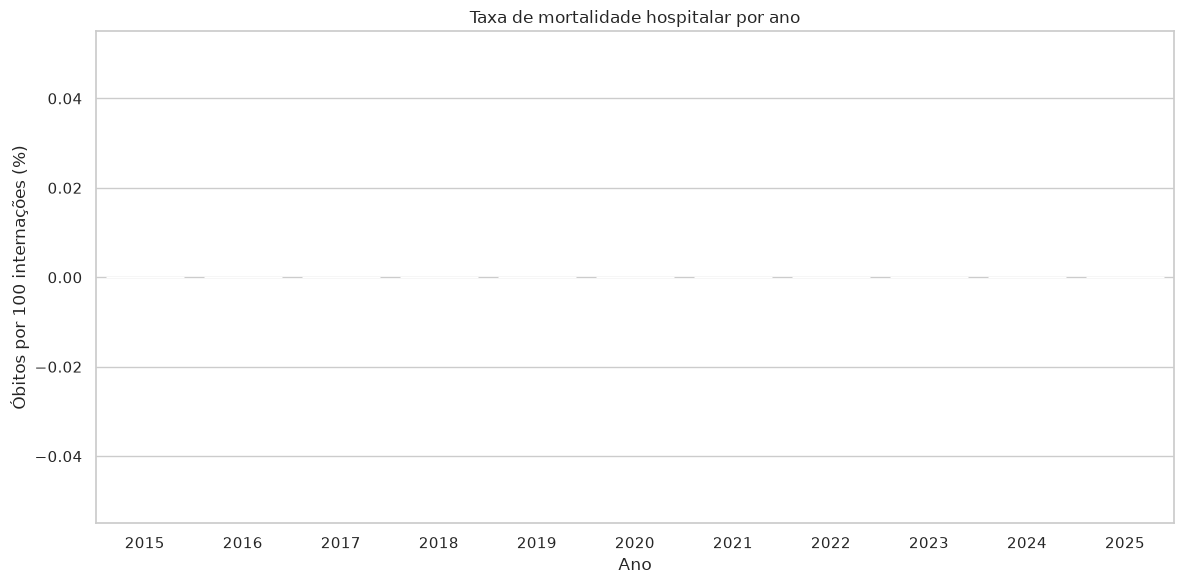

Não foram identificados óbitos nos registros analisados. Nesse caso, a ausência também deve ser relatada como resultado.


In [15]:
mortalidade_anual = (
    df.groupby("ANO_CMPT")
    .agg(
        internacoes=("DIAG_PRINC", "size"),
        obitos=("MORTE", "sum")
    )
    .reset_index()
)

mortalidade_anual["taxa_mortalidade"] = (
    mortalidade_anual["obitos"]
    / mortalidade_anual["internacoes"]
    * 100
)

display(mortalidade_anual)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=mortalidade_anual,
    x="ANO_CMPT",
    y="taxa_mortalidade"
)

plt.title("Taxa de mortalidade hospitalar por ano")
plt.xlabel("Ano")
plt.ylabel("Óbitos por 100 internações (%)")
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "07_mortalidade.png", dpi=300)
plt.show()

if mortalidade_anual["obitos"].sum() == 0:
    print(
        "Não foram identificados óbitos nos registros analisados. "
        "Nesse caso, a ausência também deve ser relatada como resultado."
    )

## Pergunta 7 — Como evoluíram os gastos hospitalares?

Os valores apresentados são nominais, isto é, não foram corrigidos pela inflação. Portanto, aumentos ao longo do tempo não devem ser atribuídos exclusivamente a maior utilização de recursos.


,ANO_CMPT,internacoes,valor_total,custo_medio,custo_mediano
0,2015,77,"48,409.11",628.69,347.90
1,2016,126,"71,704.89",569.09,372.75
2,2017,21,"12,584.22",599.25,596.41
3,2018,66,"41,047.41",621.93,114.50
4,2019,40,"16,754.52",418.86,143.05
5,2020,83,"50,557.12",609.12,171.00
6,2021,21,"9,109.51",433.79,57.00
7,2022,116,"42,940.88",370.18,114.00
8,2023,65,"9,984.86",153.61,57.00
9,2024,152,"22,535.45",148.26,57.00


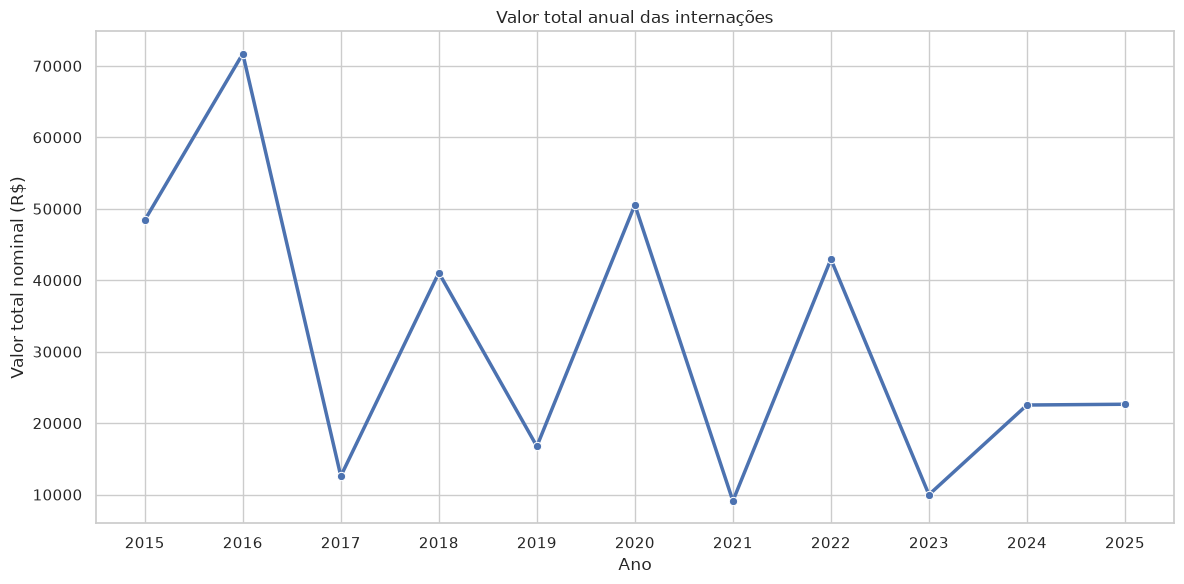

In [16]:
gastos = df.dropna(subset=["VAL_TOT"]).copy()
gastos = gastos[gastos["VAL_TOT"] >= 0]

gastos_anuais = (
    gastos.groupby("ANO_CMPT")
    .agg(
        internacoes=("DIAG_PRINC", "size"),
        valor_total=("VAL_TOT", "sum"),
        custo_medio=("VAL_TOT", "mean"),
        custo_mediano=("VAL_TOT", "median")
    )
    .reset_index()
)

display(gastos_anuais)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=gastos_anuais,
    x="ANO_CMPT",
    y="valor_total",
    marker="o",
    linewidth=2.5
)

plt.title("Valor total anual das internações")
plt.xlabel("Ano")
plt.ylabel("Valor total nominal (R$)")
plt.xticks(gastos_anuais["ANO_CMPT"])
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "08_gastos_hospitalares.png", dpi=300)
plt.show()

## Pergunta 8 — Existe uma tendência linear na idade mediana das internações por episódio depressivo?

Esta pergunta atende ao requisito de utilização de **regressão linear**.

A variável explicativa é o ano e a variável resposta é a idade mediana anual no grupo de episódio depressivo. O coeficiente angular indica a variação média estimada da mediana a cada ano.

A regressão identifica associação temporal, mas não estabelece causalidade.


In [17]:
dados_regressao = (
    perfil_etario[
        (perfil_etario["GRUPO_CID"] == "Episódio depressivo")
        & (perfil_etario["n"] >= 10)
    ]
    .dropna(subset=["idade_mediana"])
    .sort_values("ANO_CMPT")
    .copy()
)

X = dados_regressao[["ANO_CMPT"]]
y = dados_regressao["idade_mediana"]

modelo = LinearRegression()
modelo.fit(X, y)

dados_regressao["idade_estimada"] = modelo.predict(X)

coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_
r2 = r2_score(y, dados_regressao["idade_estimada"])

display(dados_regressao)

print(f"Coeficiente angular: {coeficiente:.3f} ano de idade por ano calendário")
print(f"Intercepto: {intercepto:.3f}")
print(f"R²: {r2:.3f}")

if coeficiente < 0:
    print(
        "O modelo estimou uma redução da idade mediana ao longo do período."
    )
elif coeficiente > 0:
    print(
        "O modelo estimou um aumento da idade mediana ao longo do período."
    )
else:
    print(
        "O modelo não estimou variação da idade mediana ao longo do período."
    )

,ANO_CMPT,GRUPO_CID,n,idade_mediana,idade_media,idade_minima,idade_maxima,idade_estimada
0,2015,Episódio depressivo,50,39.00,41.28,18,73,40.77
3,2016,Episódio depressivo,64,42.00,39.19,14,71,39.63
6,2017,Episódio depressivo,10,33.50,37.70,19,64,38.48
9,2018,Episódio depressivo,46,37.50,36.33,17,56,37.34
11,2019,Episódio depressivo,31,42.00,39.97,12,76,36.19
14,2020,Episódio depressivo,63,39.00,42.27,13,77,35.05
17,2021,Episódio depressivo,16,31.50,34.69,16,77,33.90
20,2022,Episódio depressivo,94,32.00,34.89,13,70,32.75
23,2023,Episódio depressivo,54,28.00,31.46,14,60,31.61
26,2024,Episódio depressivo,109,30.00,31.90,11,74,30.46


Coeficiente angular: -1.145 ano de idade por ano calendário
Intercepto: 2348.864
R²: 0.578
O modelo estimou uma redução da idade mediana ao longo do período.


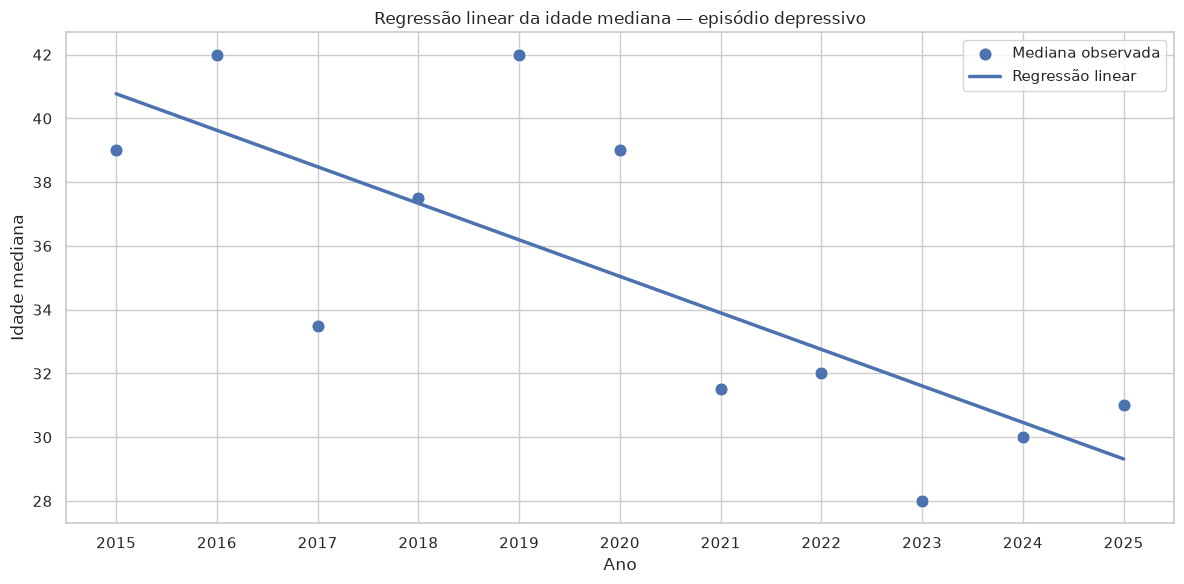

In [18]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=dados_regressao,
    x="ANO_CMPT",
    y="idade_mediana",
    s=90,
    label="Mediana observada"
)

sns.lineplot(
    data=dados_regressao,
    x="ANO_CMPT",
    y="idade_estimada",
    linewidth=2.5,
    label="Regressão linear"
)

plt.title("Regressão linear da idade mediana — episódio depressivo")
plt.xlabel("Ano")
plt.ylabel("Idade mediana")
plt.xticks(dados_regressao["ANO_CMPT"])
plt.legend()
plt.tight_layout()
plt.savefig(PASTA_SAIDA / "09_regressao_idade.png", dpi=300)
plt.show()

## 6. Síntese automática dos principais resultados


In [19]:
grupo_principal = distribuicao_cid.iloc[0]

print("RESUMO DOS RESULTADOS")
print("-" * 60)

print(
    f"1. Foram analisadas {len(df)} internações entre "
    f"{df['ANO_CMPT'].min()} e {df['ANO_CMPT'].max()}."
)

print(
    f"2. O grupo mais frequente foi '{grupo_principal['grupo']}', "
    f"com {int(grupo_principal['internacoes'])} registros "
    f"({grupo_principal['percentual']:.1f}%)."
)

print(
    f"3. O maior total anual ocorreu em "
    f"{int(ano_maior['ANO_CMPT'])}, com "
    f"{int(ano_maior['internacoes'])} internações."
)

print(
    f"4. A regressão da idade mediana para episódio depressivo "
    f"apresentou coeficiente de {coeficiente:.3f} e R² de {r2:.3f}."
)

print(
    "5. Os resultados devem ser interpretados como indicadores "
    "das internações registradas, não como prevalência total "
    "dos transtornos na população."
)

RESUMO DOS RESULTADOS
------------------------------------------------------------
1. Foram analisadas 874 internações entre 2015 e 2025.
2. O grupo mais frequente foi 'Episódio depressivo', com 629 registros (72.0%).
3. O maior total anual ocorreu em 2024, com 152 internações.
4. A regressão da idade mediana para episódio depressivo apresentou coeficiente de -1.145 e R² de 0.578.
5. Os resultados devem ser interpretados como indicadores das internações registradas, não como prevalência total dos transtornos na população.


## 7. Conclusão

A análise permitiu observar a evolução das internações relacionadas à saúde mental na Paraíba entre 2015 e 2025, identificar a predominância dos grupos diagnósticos, comparar o perfil por sexo e idade e avaliar indicadores hospitalares como permanência, mortalidade e gastos.

A série de episódios depressivos possui maior quantidade de observações e, por isso, oferece maior estabilidade para a análise temporal. Os transtornos ansiosos apresentam poucas internações em vários anos, o que limita interpretações sobre tendências desse grupo.

A regressão linear foi utilizada para avaliar a tendência da idade mediana nas internações por episódio depressivo. O coeficiente e o R² devem ser interpretados em conjunto: o coeficiente indica a direção e a intensidade média da mudança, enquanto o R² indica quanto da variação observada é explicada pela tendência linear.




## 8. Exportação das tabelas

A célula abaixo salva as principais tabelas utilizadas no relatório.


In [20]:
PASTA_TABELAS = Path("data/analytics")
PASTA_TABELAS.mkdir(parents=True, exist_ok=True)

tabelas = {
    "internacoes_anuais.csv": internacoes_anuais,
    "distribuicao_diagnosticos.csv": distribuicao_cid,
    "distribuicao_sexo.csv": sexo_diagnostico,
    "perfil_etario.csv": perfil_etario,
    "tempo_permanencia.csv": permanencia_anual,
    "mortalidade.csv": mortalidade_anual,
    "gastos_hospitalares.csv": gastos_anuais,
    "regressao_idade.csv": dados_regressao
}

for nome, tabela in tabelas.items():
    caminho = PASTA_TABELAS / nome
    tabela.to_csv(
        caminho,
        index=False,
        sep=";",
        encoding="utf-8-sig"
    )
    print(f"Salvo: {caminho}")

Salvo: data/analytics/internacoes_anuais.csv
Salvo: data/analytics/distribuicao_diagnosticos.csv
Salvo: data/analytics/distribuicao_sexo.csv
Salvo: data/analytics/perfil_etario.csv
Salvo: data/analytics/tempo_permanencia.csv
Salvo: data/analytics/mortalidade.csv
Salvo: data/analytics/gastos_hospitalares.csv
Salvo: data/analytics/regressao_idade.csv
